# Polynomial Regression with Cross-Validation
## Data Generation and Model Evaluation

## Project Overview: Polynomial Regression & Bias-Variance Tradeoff

This notebook demonstrates the application of **K‑Fold Cross‑Validation** to evaluate the performance of polynomial regression models of varying complexity on a synthetic noisy dataset.

### Workflow Summary
1. **Data Generation**  
   A synthetic dataset of 500 points is created using the function:  
   $$ y = 3 \cdot \sin(2x) + 0.5 \cdot x + \varepsilon $$
   where `ε` is Gaussian noise.  
2. **Cross‑Validation Setup**  
   The dataset is randomly split into **10 equal folds** using `KFold` with shuffling.  
3. **Model Training & Evaluation**  
   For each fold, polynomial models of **degrees 1 through 25** are trained on 9 folds and evaluated on the remaining 1 fold using **Mean Squared Error (MSE)**.  
4. **Performance Aggregation**  
   For each degree, the **mean** and **variance** of the 10 MSE scores are calculated to analyze model stability and accuracy.  
5. **Visualization & Interpretation**  
   - Plots of mean and variance versus polynomial degree clearly illustrate the **bias–variance tradeoff**.  
   - The best (lowest mean MSE) and worst (highest mean MSE) models are visually compared against the original data.

### 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

### 2. Generate Synthetic Data
We create 500 noisy samples from a nonlinear function.
$$ y = 3 \cdot \sin(2x) + 0.5 \cdot x + \varepsilon $$
where $$ \varepsilon \sim \mathcal{N}(0, 0.3^2) $$

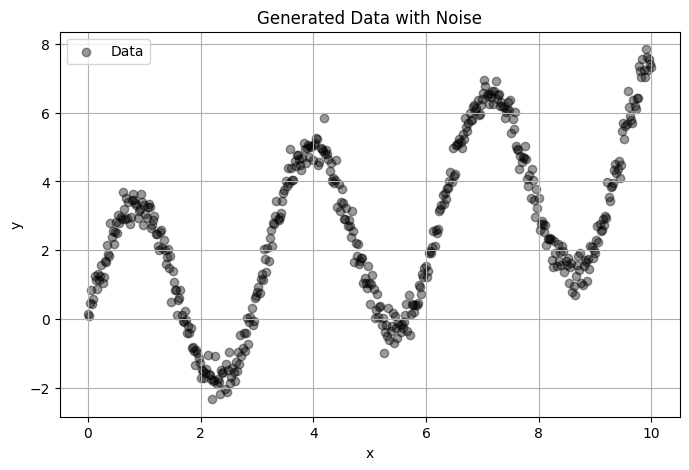

In [2]:
random_state = 42
np.random.seed(random_state)

x = np.linspace(0, 10, 500)
e = np.random.normal(0, 0.3, x.shape[0])
y = 3 * np.sin(2 * x) + 0.5 * x + e

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='black', alpha=0.4, label='Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data with Noise')
plt.grid(True)
plt.legend()
plt.show()

### 3. 10-Fold Cross-Validation Setup
We split the data into 10 equal folds (shuffled).

In [3]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

### 4. Train Polynomial Models for Degrees 1–25
For each fold and each polynomial degree, we fit a model and compute MSE on the validation fold.

In [4]:
X = x.reshape(-1, 1)
degrees = list(range(1, 26))
mse_scores = {degree: [] for degree in degrees}

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    for degree in degrees:
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_val_poly = poly.transform(X_val)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_val_poly)
        mse = mean_squared_error(y_val, y_pred)
        mse_scores[degree].append(mse)

### 5. Compute Mean and Variance of MSE for Each Degree

In [5]:
mean_mses = [np.mean(mse_scores[d]) for d in degrees]
var_mses = [np.var(mse_scores[d]) for d in degrees]

print(f"{'Degree':<8} | {'Mean MSE':<12} | {'Variance MSE':<12}")
print("-" * 38)
for d in degrees:
    print(f"{d:<8} | {mean_mses[d-1]:<12.4f} | {var_mses[d-1]:<12.4f}")

Degree   | Mean MSE     | Variance MSE
--------------------------------------
1        | 4.4403       | 0.0566      
2        | 4.3677       | 0.0631      
3        | 4.3247       | 0.0628      
4        | 4.0685       | 0.0390      
5        | 3.8355       | 0.0935      
6        | 3.7848       | 0.0786      
7        | 2.6144       | 0.0930      
8        | 1.9253       | 0.1355      
9        | 0.5691       | 0.0049      
10       | 0.3121       | 0.0043      
11       | 0.1322       | 0.0004      
12       | 0.1748       | 0.0004      
13       | 0.6471       | 0.0303      
14       | 0.5408       | 0.3043      
15       | 1.8659       | 0.1704      
16       | 1.6262       | 0.1492      
17       | 1.5575       | 0.1069      
18       | 2.7246       | 0.1929      
19       | 2.6733       | 0.2320      
20       | 2.5954       | 0.2390      
21       | 2.5553       | 0.2239      
22       | 2.5670       | 0.2025      
23       | 2.6129       | 0.1847      
24       | 2.6663       |

### 6. Plot Mean and Variance of MSE vs. Degree
These plots illustrate the bias–variance tradeoff.

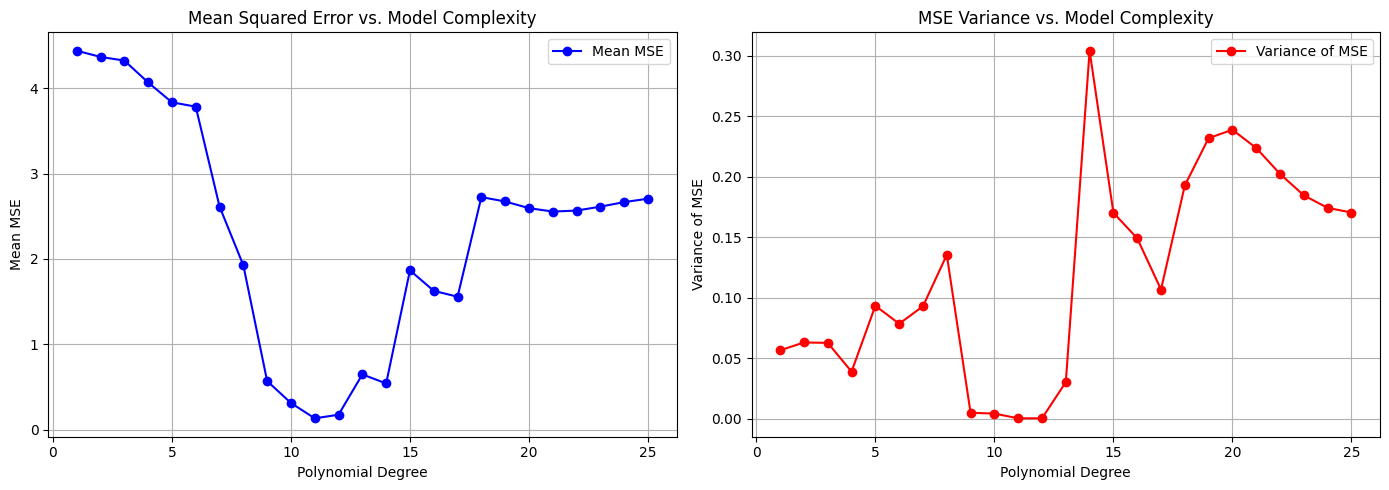

In [6]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees, mean_mses, marker='o', linestyle='-', color='b', label='Mean MSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean MSE')
plt.title('Mean Squared Error vs. Model Complexity')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(degrees, var_mses, marker='o', linestyle='-', color='r', label='Variance of MSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('Variance of MSE')
plt.title('MSE Variance vs. Model Complexity')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### 7. Interpretation of Bias–Variance Tradeoff
- **Low degrees (1–5):** High bias (underfitting) → high mean MSE, low variance.
- **Moderate degrees (9–12):** Optimal complexity → lowest mean MSE with relatively low variance.
- **High degrees (≥13):** High variance (overfitting) → mean MSE increases again and variance grows significantly.

This pattern clearly demonstrates the bias–variance tradeoff: as model complexity increases, bias decreases but variance increases.

### 8. Best and Worst Degrees (Visualisation)

Best degree: 11 (Mean MSE = 0.1322)
Worst degree: 1 (Mean MSE = 4.4403)


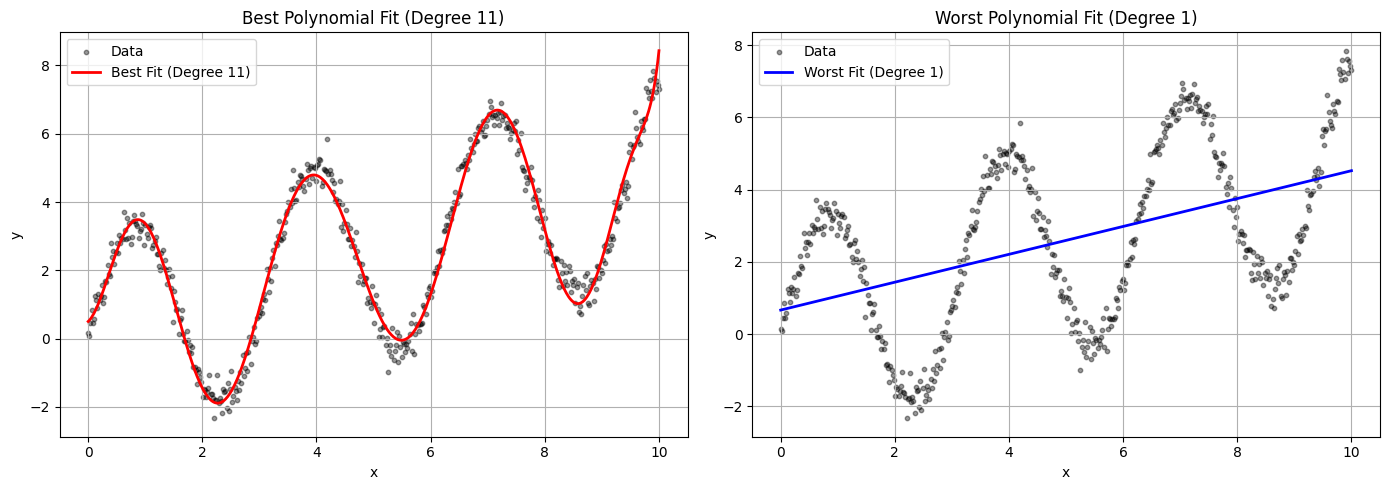

In [7]:
best_degree = degrees[np.argmin(mean_mses)]
worst_degree = degrees[np.argmax(mean_mses)]

print(f"Best degree: {best_degree} (Mean MSE = {mean_mses[best_degree-1]:.4f})")
print(f"Worst degree: {worst_degree} (Mean MSE = {mean_mses[worst_degree-1]:.4f})")

poly_best = PolynomialFeatures(degree=best_degree)
X_poly_best = poly_best.fit_transform(X)
model_best = LinearRegression().fit(X_poly_best, y)
y_pred_best = model_best.predict(X_poly_best)

poly_worst = PolynomialFeatures(degree=worst_degree)
X_poly_worst = poly_worst.fit_transform(X)
model_worst = LinearRegression().fit(X_poly_worst, y)
y_pred_worst = model_worst.predict(X_poly_worst)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(x, y, color='black', alpha=0.4, label='Data', s=10)
plt.plot(x, y_pred_best, color='red', linewidth=2, label=f'Best Fit (Degree {best_degree})')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Best Polynomial Fit (Degree {best_degree})')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x, y, color='black', alpha=0.4, label='Data', s=10)
plt.plot(x, y_pred_worst, color='blue', linewidth=2, label=f'Worst Fit (Degree {worst_degree})')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Worst Polynomial Fit (Degree {worst_degree})')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 9. Additional Fits for Random Degrees (Visualisation)
This shows how different complexities fit the data.

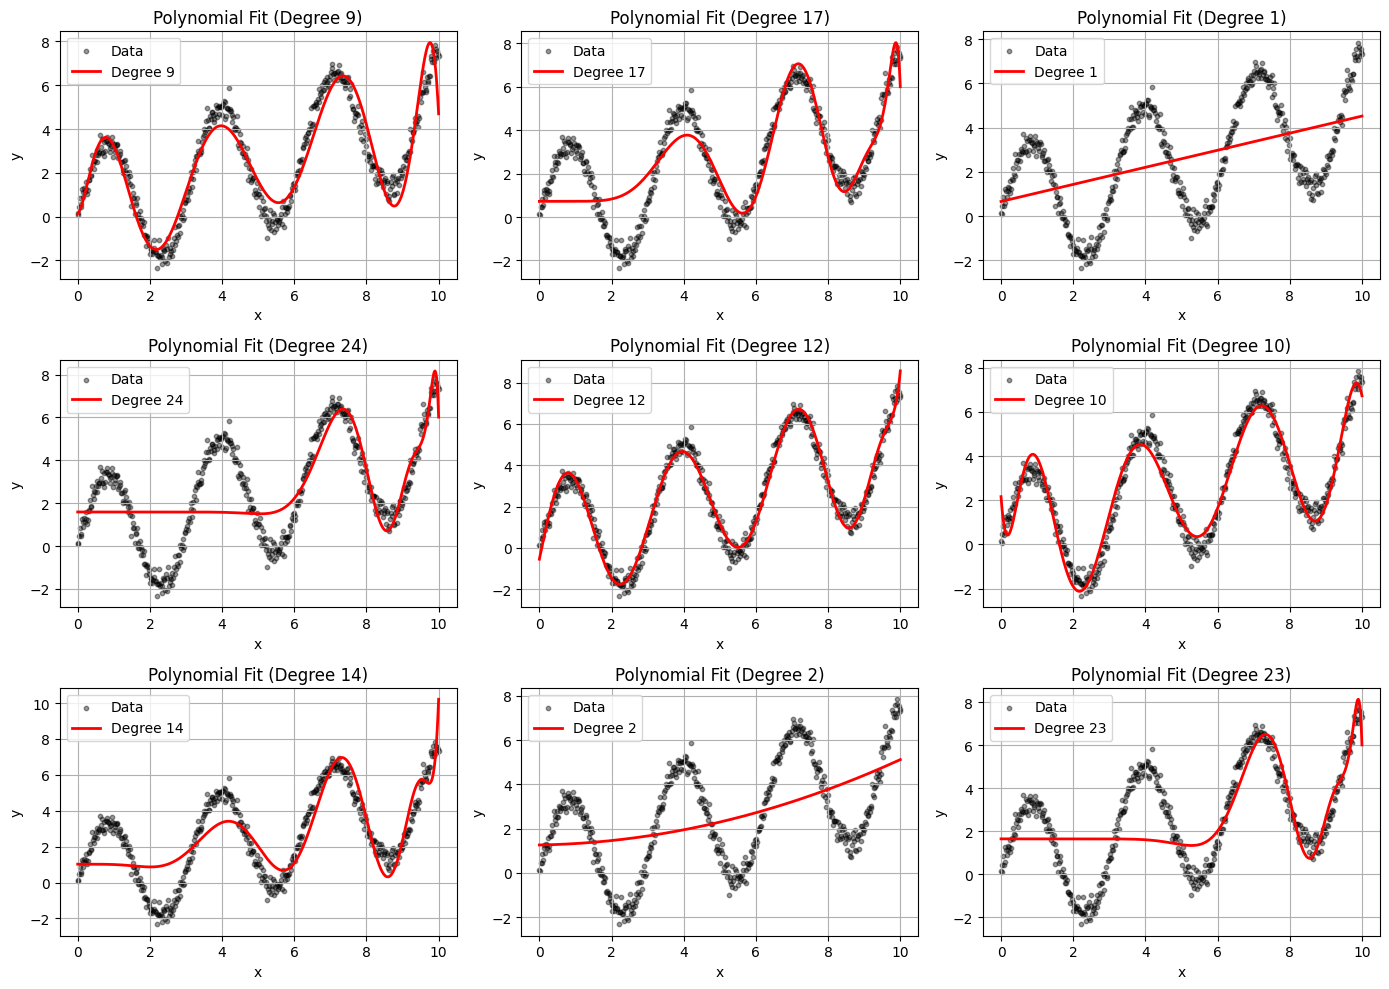

In [8]:
np.random.seed(random_state)
random_degrees = np.random.choice(degrees, 9, replace=False)

plt.figure(figsize=(14, 10))
for i, degree in enumerate(random_degrees):
    plt.subplot(3, 3, i + 1)
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    plt.scatter(x, y, color='black', alpha=0.4, label='Data', s=10)
    plt.plot(x, y_pred, color='red', linewidth=2, label=f'Degree {degree}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Polynomial Fit (Degree {degree})')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()